# Dream the Road — Tiny Dreamer for Highway-env

**Name:** Ankita Tank 
**Course:** CSC 580 
**Assignment:** Final Project  
**AI Tools Consulted:** GitHub Copilot (Claude), PyTorch documentation, Dreamer V1 paper (Hafner et al., 2020)  

---

## Project Overview

This notebook implements a **Dreamer V1**-style world model for the **highway-v0** environment from
[Highway-Env](https://github.com/Farama-Foundation/HighwayEnv). The agent learns to drive at
high speed while avoiding collisions, entirely through **latent imagination**.

### Architecture

| Component | Role |
|---|---|
| **Encoder** (CNN) | Maps RGB frames → latent embeddings |
| **RSSM** (GRU-based) | Recurrent State-Space Model for latent dynamics |
| **Reward Model** (MLP) | Predicts scalar reward from latent state |
| **Decoder** (Transposed CNN) | Reconstructs RGB frames from latent state |
| **Actor** (MLP) | Outputs continuous actions (throttle + steering) |
| **Critic** (MLP) | Estimates value of latent states |

### Training Loop

1. Collect random transitions (warm start) into a replay buffer  
2. Train world dynamics (Encoder + RSSM + Reward + Decoder) from replay buffer  
3. Train Actor-Critic via imagined rollouts in the learned world model  
4. Act in the real environment using the learned policy, store transitions  
5. Repeat steps 2–4  

---
## 1. Setup & Imports

In [ ]:
!pip install gymnasium highway-env torch torchvision matplotlib imageio numpy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import os
import random
from collections import deque
from dataclasses import dataclass

import gymnasium as gym
import highway_env  # registers highway-v0
import numpy as np
import matplotlib.pyplot as plt
import imageio

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")
print("✅ All imports successful.")

PyTorch version : 2.8.0
CUDA available  : False
Using device    : cpu
✅ All imports successful.


---
## 2. Hyperparameters & Configuration

All tuneable constants are gathered here for easy experimentation.

In [3]:
@dataclass
class Config:
    """Central configuration for the Tiny Dreamer system."""

    # --- Environment ---
    ENV_NAME: str = "highway-v0"
    IMG_HEIGHT: int = 64                # Resized observation height
    IMG_WIDTH: int = 64                 # Resized observation width
    IMG_CHANNELS: int = 3               # RGB channels
    ACTION_DIM: int = 2                 # Continuous: [throttle, steering]
    LANES_COUNT: int = 4                # Number of lanes on the highway

    # --- Replay Buffer ---
    BUFFER_CAPACITY: int = 50_000       # Maximum transitions stored
    WARM_START_STEPS: int = 2_000       # Random exploration steps before training
    SEQ_LEN: int = 16                   # Sequence length for RSSM training
    BATCH_SIZE: int = 32                # Mini-batch size for world model training

    # --- World Model (RSSM) ---
    LATENT_DIM: int = 64                # Stochastic state dimension
    DETERMINISTIC_DIM: int = 128        # GRU hidden (deterministic) state dimension
    HIDDEN_DIM: int = 128               # MLP hidden layer width
    EMBED_DIM: int = 256                # CNN encoder output dimension

    # --- Actor-Critic ---
    IMAGINATION_HORIZON: int = 15       # Steps to imagine for actor-critic training
    GAMMA: float = 0.99                 # Discount factor
    LAMBDA_: float = 0.95               # GAE lambda for value targets
    ACTOR_LR: float = 3e-4              # Actor learning rate
    CRITIC_LR: float = 3e-4             # Critic learning rate
    WORLD_LR: float = 3e-4              # World model learning rate
    MAX_GRAD_NORM: float = 100.0        # Gradient clipping norm
    ENTROPY_SCALE: float = 1e-3         # Entropy bonus coefficient

    # --- Training ---
    TOTAL_TRAIN_ITERS: int = 100        # Outer training iterations
    WORLD_TRAIN_STEPS: int = 50         # World model gradient steps per iteration
    ACTOR_CRITIC_STEPS: int = 30        # Actor-critic gradient steps per iteration
    ENV_STEPS_PER_ITER: int = 200       # Real environment steps per iteration
    EVAL_INTERVAL: int = 10             # Evaluate every N iterations
    SAVE_VIDEO_INTERVAL: int = 25       # Save prediction video every N iterations

    # --- Paths ---
    VIDEO_DIR: str = "videos"           # Directory for saving output videos


cfg = Config()
os.makedirs(cfg.VIDEO_DIR, exist_ok=True)
print("✅ Configuration loaded.")
print(f"   Latent dim        = {cfg.LATENT_DIM}")
print(f"   Deterministic dim = {cfg.DETERMINISTIC_DIM}")
print(f"   Batch size        = {cfg.BATCH_SIZE}")
print(f"   Sequence length   = {cfg.SEQ_LEN}")

✅ Configuration loaded.
   Latent dim        = 64
   Deterministic dim = 128
   Batch size        = 32
   Sequence length   = 16


---
## 3. Environment Setup

We configure **highway-v0** with:
- `render_mode="rgb_array"` so we can capture frames as pixel observations
- Continuous action space (throttle and steering)
- 4 lanes for richer driving scenarios

Raw frame shape       : (150, 600, 3)
Processed frame shape : (3, 64, 64)
Pixel range           : [0.00, 1.00]


objc[7273]: Class SDLApplication is implemented in both /Users/tanka1/Library/Python/3.9/lib/python/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x132c8d2c8) and /Users/tanka1/Library/Python/3.9/lib/python/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x167708890). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7273]: Class SDLAppDelegate is implemented in both /Users/tanka1/Library/Python/3.9/lib/python/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x132c8d318) and /Users/tanka1/Library/Python/3.9/lib/python/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x1677088e0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[7273]: Class SDLTranslatorResponder is implemented in both /Users/tanka1/Library/Python/3.9/lib/python/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x132c8d390) and /Users/tanka1/Library/Python/3.9/lib/python/site-pa

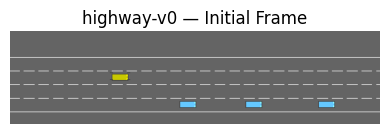

✅ Environment configured.


In [4]:
def make_env(cfg: Config) -> gym.Env:
    """Create and configure the highway-v0 environment."""
    env = gym.make(cfg.ENV_NAME, render_mode="rgb_array")
    env.unwrapped.configure({
        "action": {
            "type": "ContinuousAction",
            "longitudinal": True,
            "lateral": True,
        },
        "lanes_count": cfg.LANES_COUNT,
        "observation": {
            "type": "Kinematics",   # Doesn't require rendering during step()
        },
        # Raise policy frequency from the default 1 Hz to 5 Hz so that each
        # action only persists for 3 simulation steps (15/5) instead of 15.
        # At 1 Hz a single max-steering input lasts a full second — long enough
        # for the car to complete a near-full circle.  At 5 Hz the turns are
        # short and correctable, eliminating the spinning artefact.
        "simulation_frequency": 15,
        "policy_frequency": 5,
        "duration": 40,             # Episode length in seconds (= 200 steps at 5 Hz)
        # Terminate immediately when the ego car leaves the road.  Without
        # this flag the car can spin off-track indefinitely, flooding the
        # replay buffer with degenerate off-road transitions.
        "offroad_terminal": True,
        "normalize_reward": True,
        "reward_speed_range": [20, 30],  # Reward band aligned with highway cruising speed
        "collision_reward": -1,
        "high_speed_reward": 0.4,
        "right_lane_reward": 0.1,
        "lane_change_reward": 0,
    })
    env.reset()
    # Force the viewer/renderer to initialize immediately
    env.render()
    return env


def preprocess_frame(frame: np.ndarray, cfg: Config) -> np.ndarray:
    """Resize an RGB frame to (C, H, W) float32 in [0, 1].

    Args:
        frame: Raw RGB frame from env.render(), shape (H_raw, W_raw, 3).
        cfg:   Configuration with target height/width.

    Returns:
        Preprocessed frame of shape (3, IMG_HEIGHT, IMG_WIDTH), values in [0, 1].
    """
    import cv2
    resized = cv2.resize(frame, (cfg.IMG_WIDTH, cfg.IMG_HEIGHT),
                         interpolation=cv2.INTER_AREA)
    # Convert HWC -> CHW and normalize to [0, 1]
    return resized.transpose(2, 0, 1).astype(np.float32) / 255.0


# Quick test: create the environment and render a frame
test_env = make_env(cfg)
test_obs, _ = test_env.reset()
test_frame = test_env.render()
test_processed = preprocess_frame(test_frame, cfg)
print(f"Raw frame shape       : {test_frame.shape}")
print(f"Processed frame shape : {test_processed.shape}")
print(f"Pixel range           : [{test_processed.min():.2f}, {test_processed.max():.2f}]")

# Display the initial frame
plt.figure(figsize=(4, 4))
plt.imshow(test_frame)
plt.title("highway-v0 — Initial Frame")
plt.axis("off")
plt.tight_layout()
plt.show()
test_env.close()
print("✅ Environment configured.")


---
## 4. Replay Buffer

The replay buffer stores transitions `(frame, action, reward, next_frame, done)` collected
from real environment interactions. The world dynamics model is trained by sampling **sequences**
of consecutive transitions from this buffer (because the RSSM is a recurrent model).

In [5]:
class ReplayBuffer:
    """Fixed-capacity replay buffer that stores full transitions.

    Each transition consists of:
        - frame:      Preprocessed RGB image, shape (C, H, W).
        - action:     Continuous action vector, shape (ACTION_DIM,).
        - reward:     Scalar reward.
        - next_frame: Preprocessed next RGB image, shape (C, H, W).
        - done:       Boolean indicating episode termination.

    Supports sampling contiguous sequences of length `seq_len` for RSSM training.
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.frames = []       # List of (C, H, W) arrays
        self.actions = []      # List of (ACTION_DIM,) arrays
        self.rewards = []      # List of float
        self.next_frames = []  # List of (C, H, W) arrays
        self.dones = []        # List of bool
        self.episode_starts = [0]  # Indices where new episodes begin
        self._size = 0

    def add(self, frame, action, reward, next_frame, done):
        """Add a single transition to the buffer."""
        if self._size < self.capacity:
            self.frames.append(frame)
            self.actions.append(action)
            self.rewards.append(reward)
            self.next_frames.append(next_frame)
            self.dones.append(done)
            self._size += 1
        else:
            # Overwrite oldest transition (FIFO)
            idx = self._size % self.capacity
            self.frames[idx] = frame
            self.actions[idx] = action
            self.rewards[idx] = reward
            self.next_frames[idx] = next_frame
            self.dones[idx] = done
            self._size += 1

        # Track episode boundaries for sequence sampling
        if done:
            self.episode_starts.append(min(self._size, self.capacity))

    def sample_sequences(self, batch_size: int, seq_len: int):
        """Sample a batch of contiguous sequences that do not cross episode boundaries.

        Returns:
            frames:  Tensor of shape (batch_size, seq_len, C, H, W)
            actions: Tensor of shape (batch_size, seq_len, ACTION_DIM)
            rewards: Tensor of shape (batch_size, seq_len)
        """
        current_size = min(self._size, self.capacity)

        # Build list of valid starting indices (sequence does not cross episode end)
        valid_starts = []
        for i in range(current_size - seq_len):
            # Check that no 'done' flag is True within positions i..i+seq_len-2
            # (the last step can be done — we just need contiguous frames)
            if not any(self.dones[i + j] for j in range(seq_len - 1)):
                valid_starts.append(i)

        if len(valid_starts) < batch_size:
            # Fall back: sample with replacement if not enough valid starts
            chosen = random.choices(valid_starts, k=batch_size)
        else:
            chosen = random.sample(valid_starts, batch_size)

        # Build tensors
        batch_frames = np.stack(
            [np.stack([self.frames[s + t] for t in range(seq_len)]) for s in chosen]
        )
        batch_actions = np.stack(
            [np.stack([self.actions[s + t] for t in range(seq_len)]) for s in chosen]
        )
        batch_rewards = np.stack(
            [np.array([self.rewards[s + t] for t in range(seq_len)]) for s in chosen]
        )

        return (
            torch.tensor(batch_frames, dtype=torch.float32, device=DEVICE),
            torch.tensor(batch_actions, dtype=torch.float32, device=DEVICE),
            torch.tensor(batch_rewards, dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return min(self._size, self.capacity)


print("✅ ReplayBuffer defined.")

✅ ReplayBuffer defined.


---
## 5. World Dynamics Model

The world dynamics model follows the **Dreamer V1** architecture:

1. **Encoder** — A convolutional network that compresses an RGB frame into a flat embedding vector.
2. **RSSM** (Recurrent State-Space Model) — Maintains both a **deterministic** recurrent state
   (via a GRU) and a **stochastic** latent state. This captures both the predictable dynamics
   and the inherent uncertainty of the environment.
3. **Reward Model** — An MLP that predicts the immediate reward from the combined latent state.
4. **Decoder** — A transposed-convolutional network that reconstructs the RGB frame from the
   latent state (used for visualization and as a reconstruction loss signal).

### 5.1 Encoder (Image → Latent Embedding)

In [6]:
class ConvEncoder(nn.Module):
    """CNN encoder that maps an RGB image to a flat embedding vector.

    Architecture:
        Conv2d(3  → 32, 4×4, stride 2) → ReLU
        Conv2d(32 → 64, 4×4, stride 2) → ReLU
        Conv2d(64 → 128, 4×4, stride 2) → ReLU
        Conv2d(128 → 256, 4×4, stride 2) → ReLU
        Flatten → Linear → embed_dim

    For 64×64 input, the spatial dimensions reduce as:
        64 → 31 → 14 → 6 → 2  (before flatten: 256×2×2 = 1024)
    """

    def __init__(self, img_channels: int, embed_dim: int):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(img_channels, 32, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2),
            nn.ReLU(),
        )
        # Compute flattened feature size dynamically
        with torch.no_grad():
            dummy = torch.zeros(1, img_channels, 64, 64)
            conv_out = self.convs(dummy)
            self._conv_out_size = conv_out.view(1, -1).shape[1]

        self.fc = nn.Linear(self._conv_out_size, embed_dim)

    def forward(self, obs):
        """Encode a batch of images.

        Args:
            obs: Tensor of shape (B, C, H, W) with pixel values in [0, 1].

        Returns:
            Embedding tensor of shape (B, embed_dim).
        """
        x = self.convs(obs)
        x = x.view(x.size(0), -1)  # Flatten spatial dims
        return self.fc(x)


print("✅ ConvEncoder defined.")

✅ ConvEncoder defined.


### 5.2 Decoder (Latent → Reconstructed Image)

In [7]:
class ConvDecoder(nn.Module):
    """Transposed-CNN decoder that reconstructs an RGB image from the latent state.

    The input is the concatenation of the deterministic state (h) and
    the stochastic state (z), giving a vector of size
    (deterministic_dim + latent_dim).

    Architecture mirrors the encoder in reverse:
        Linear → Reshape(256, 2, 2)
        ConvTranspose2d(256 → 128, 4×4, stride 2) → ReLU
        ConvTranspose2d(128 → 64,  4×4, stride 2) → ReLU
        ConvTranspose2d(64  → 32,  5×5, stride 2) → ReLU
        ConvTranspose2d(32  → 3,   6×6, stride 2) → Sigmoid
    """

    def __init__(self, latent_dim: int, deterministic_dim: int, img_channels: int):
        super().__init__()
        self.fc = nn.Linear(deterministic_dim + latent_dim, 256 * 2 * 2)
        self.deconvs = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=2, padding=0),
            nn.ReLU(),
            nn.ConvTranspose2d(32, img_channels, kernel_size=6, stride=2, padding=1),
            nn.Sigmoid(),  # Output pixels in [0, 1]
        )

    def forward(self, h, z):
        """Decode latent state to a reconstructed image.

        Args:
            h: Deterministic state, shape (B, deterministic_dim).
            z: Stochastic state, shape (B, latent_dim).

        Returns:
            Reconstructed image, shape (B, C, 64, 64), values in [0, 1].
        """
        x = self.fc(torch.cat([h, z], dim=-1))
        x = x.view(-1, 256, 2, 2)  # Reshape to spatial
        return self.deconvs(x)


print("✅ ConvDecoder defined.")

✅ ConvDecoder defined.


### 5.3 RSSM — Recurrent State-Space Model

The RSSM is the core of the Dreamer world model. It maintains two types of state:

- **Deterministic state** ($h_t$): Updated by a GRU cell, captures long-term temporal dependencies.
- **Stochastic state** ($z_t$): Sampled from a diagonal Gaussian, captures uncertainty.

Two distributions are maintained:
- **Prior** $p(z_t | h_t)$: Predicted from the deterministic state alone (for imagination).
- **Posterior** $q(z_t | h_t, e_t)$: Conditioned on both the deterministic state and the actual
  observation embedding $e_t$ (for training with real data).

During training, the KL divergence between prior and posterior is minimized so the model
learns to predict future states accurately even without observations.

In [8]:
class RSSM(nn.Module):
    """Recurrent State-Space Model following Dreamer V1.

    The RSSM combines a GRU for deterministic transitions with
    Gaussian latent variables for stochastic transitions.

    Notation:
        h_t : deterministic state (GRU hidden), size = deterministic_dim
        z_t : stochastic latent state, size = latent_dim
        e_t : observation embedding from the encoder, size = embed_dim
        a_t : action vector, size = action_dim
    """

    def __init__(self, latent_dim: int, deterministic_dim: int,
                 embed_dim: int, action_dim: int, hidden_dim: int):
        super().__init__()
        self.latent_dim = latent_dim
        self.deterministic_dim = deterministic_dim

        # Pre-GRU MLP: projects (z_{t-1}, a_{t-1}) into GRU input space
        self.pre_gru = nn.Sequential(
            nn.Linear(latent_dim + action_dim, hidden_dim),
            nn.ReLU(),
        )
        # GRU cell: h_t = GRU(pre_gru(z_{t-1}, a_{t-1}), h_{t-1})
        self.gru_cell = nn.GRUCell(hidden_dim, deterministic_dim)

        # Prior: p(z_t | h_t)  — predicts stochastic state from deterministic only
        self.prior_net = nn.Sequential(
            nn.Linear(deterministic_dim, hidden_dim),
            nn.ReLU(),
        )
        self.prior_mean = nn.Linear(hidden_dim, latent_dim)
        self.prior_logstd = nn.Linear(hidden_dim, latent_dim)

        # Posterior: q(z_t | h_t, e_t) — uses observation embedding too
        self.posterior_net = nn.Sequential(
            nn.Linear(deterministic_dim + embed_dim, hidden_dim),
            nn.ReLU(),
        )
        self.posterior_mean = nn.Linear(hidden_dim, latent_dim)
        self.posterior_logstd = nn.Linear(hidden_dim, latent_dim)

    def initial_state(self, batch_size: int):
        """Return zero-initialized (h, z) for the start of an episode."""
        h = torch.zeros(batch_size, self.deterministic_dim, device=DEVICE)
        z = torch.zeros(batch_size, self.latent_dim, device=DEVICE)
        return h, z

    def _compute_prior(self, h):
        """Compute prior distribution p(z_t | h_t)."""
        x = self.prior_net(h)
        mean = self.prior_mean(x)
        # Clamp log-std for numerical stability
        logstd = self.prior_logstd(x).clamp(-10.0, 2.0)
        return mean, logstd

    def _compute_posterior(self, h, embed):
        """Compute posterior distribution q(z_t | h_t, e_t)."""
        x = self.posterior_net(torch.cat([h, embed], dim=-1))
        mean = self.posterior_mean(x)
        logstd = self.posterior_logstd(x).clamp(-10.0, 2.0)
        return mean, logstd

    @staticmethod
    def _sample(mean, logstd):
        """Reparameterized sampling: z = mean + std * epsilon."""
        std = logstd.exp()
        dist = Normal(mean, std)
        return dist.rsample()  # Differentiable sample

    def observe_step(self, prev_h, prev_z, prev_action, embed):
        """One step of the RSSM with a real observation (training mode).

        This uses the posterior to incorporate the actual observation.

        Args:
            prev_h:      Previous deterministic state (B, deterministic_dim)
            prev_z:      Previous stochastic state (B, latent_dim)
            prev_action: Previous action (B, action_dim)
            embed:       Current observation embedding (B, embed_dim)

        Returns:
            h:           New deterministic state
            z:           New stochastic state (sampled from posterior)
            prior_mean, prior_logstd:     Prior distribution params
            posterior_mean, posterior_logstd: Posterior distribution params
        """
        # Update deterministic state via GRU
        gru_input = self.pre_gru(torch.cat([prev_z, prev_action], dim=-1))
        h = self.gru_cell(gru_input, prev_h)

        # Compute prior and posterior
        prior_mean, prior_logstd = self._compute_prior(h)
        posterior_mean, posterior_logstd = self._compute_posterior(h, embed)

        # Sample z from posterior (training uses real observations)
        z = self._sample(posterior_mean, posterior_logstd)

        return h, z, prior_mean, prior_logstd, posterior_mean, posterior_logstd

    def imagine_step(self, prev_h, prev_z, prev_action):
        """One step of the RSSM without observation (imagination / rollout).

        Uses only the prior distribution — no real observation is available.

        Args:
            prev_h:      Previous deterministic state (B, deterministic_dim)
            prev_z:      Previous stochastic state (B, latent_dim)
            prev_action: Previous action (B, action_dim)

        Returns:
            h: New deterministic state
            z: New stochastic state (sampled from prior)
        """
        gru_input = self.pre_gru(torch.cat([prev_z, prev_action], dim=-1))
        h = self.gru_cell(gru_input, prev_h)
        prior_mean, prior_logstd = self._compute_prior(h)
        z = self._sample(prior_mean, prior_logstd)
        return h, z


print("✅ RSSM defined.")

✅ RSSM defined.


### 5.4 Reward Model

In [9]:
class RewardModel(nn.Module):
    """MLP that predicts the scalar reward from the latent state.

    Input: concatenation of deterministic state h and stochastic state z.
    Output: predicted reward (scalar).
    """

    def __init__(self, deterministic_dim: int, latent_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deterministic_dim + latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),  # Single scalar output
        )

    def forward(self, h, z):
        """Predict reward from latent state."""
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


print("✅ RewardModel defined.")

✅ RewardModel defined.


---
## 6. Actor-Critic Model

The Actor and Critic are trained on **imagined trajectories** generated by the world model.

- **Actor (Policy):** Outputs a continuous action distribution (Gaussian) given the latent state.
  It maximizes the expected imagined return.
- **Critic (Value):** Estimates the value $V(h, z)$ of a latent state, used for computing
  TD-λ value targets during imagination.

In [10]:
class Actor(nn.Module):
    """Policy network that outputs continuous actions from the latent state.

    Outputs the mean and log-std of a diagonal Gaussian over the action space.
    Actions are squashed through tanh to stay in [-1, 1].
    """

    def __init__(self, deterministic_dim: int, latent_dim: int,
                 hidden_dim: int, action_dim: int):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(deterministic_dim + latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.logstd_head = nn.Linear(hidden_dim, action_dim)

    def forward(self, h, z):
        """Compute action distribution parameters.

        Args:
            h: Deterministic state (B, deterministic_dim)
            z: Stochastic state (B, latent_dim)

        Returns:
            action: Sampled action squashed by tanh, shape (B, action_dim)
            log_prob: Log-probability of the action (B,)
        """
        x = self.trunk(torch.cat([h, z], dim=-1))
        mean = self.mean_head(x)
        logstd = self.logstd_head(x).clamp(-5.0, 2.0)
        std = logstd.exp()

        # Reparameterized sample
        dist = Normal(mean, std)
        raw_action = dist.rsample()

        # Squash through tanh for bounded actions
        action = torch.tanh(raw_action)

        # Correct log-prob for the tanh squashing (Appendix C, SAC paper)
        log_prob = dist.log_prob(raw_action).sum(-1)
        log_prob -= torch.log(1 - action.pow(2) + 1e-6).sum(-1)

        return action, log_prob


class Critic(nn.Module):
    """Value network that estimates the expected return from a latent state.

    Input:  concatenation of h (deterministic) and z (stochastic).
    Output: scalar value estimate V(h, z).
    """

    def __init__(self, deterministic_dim: int, latent_dim: int, hidden_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(deterministic_dim + latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, h, z):
        """Estimate value of latent state."""
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


print("✅ Actor and Critic defined.")

✅ Actor and Critic defined.


---
## 7. Tiny Dreamer — Full System

This class ties all components together and provides methods for:
- Training the world dynamics model (encoder, RSSM, decoder, reward model)
- Training the actor-critic via imagined rollouts
- Acting in the real environment
- Generating prediction visualizations

In [11]:
class TinyDreamer:
    """Dreamer V1-style world model agent for continuous-action environments.

    Encapsulates all neural network components (encoder, RSSM, decoder,
    reward model, actor, critic) and manages the full training loop:
    world model learning, actor-critic learning, and environment interaction.
    """

    def __init__(self, cfg: Config):
        self.cfg = cfg

        # --- World Dynamics Components ---
        self.encoder = ConvEncoder(
            img_channels=cfg.IMG_CHANNELS, embed_dim=cfg.EMBED_DIM
        ).to(DEVICE)

        self.rssm = RSSM(
            latent_dim=cfg.LATENT_DIM,
            deterministic_dim=cfg.DETERMINISTIC_DIM,
            embed_dim=cfg.EMBED_DIM,
            action_dim=cfg.ACTION_DIM,
            hidden_dim=cfg.HIDDEN_DIM,
        ).to(DEVICE)

        self.decoder = ConvDecoder(
            latent_dim=cfg.LATENT_DIM,
            deterministic_dim=cfg.DETERMINISTIC_DIM,
            img_channels=cfg.IMG_CHANNELS,
        ).to(DEVICE)

        self.reward_model = RewardModel(
            deterministic_dim=cfg.DETERMINISTIC_DIM,
            latent_dim=cfg.LATENT_DIM,
            hidden_dim=cfg.HIDDEN_DIM,
        ).to(DEVICE)

        # --- Actor-Critic Components ---
        self.actor = Actor(
            deterministic_dim=cfg.DETERMINISTIC_DIM,
            latent_dim=cfg.LATENT_DIM,
            hidden_dim=cfg.HIDDEN_DIM,
            action_dim=cfg.ACTION_DIM,
        ).to(DEVICE)

        self.critic = Critic(
            deterministic_dim=cfg.DETERMINISTIC_DIM,
            latent_dim=cfg.LATENT_DIM,
            hidden_dim=cfg.HIDDEN_DIM,
        ).to(DEVICE)

        # --- Optimizers ---
        # World model optimizer covers encoder + RSSM + decoder + reward model
        self.world_optimizer = optim.Adam(
            list(self.encoder.parameters()) +
            list(self.rssm.parameters()) +
            list(self.decoder.parameters()) +
            list(self.reward_model.parameters()),
            lr=cfg.WORLD_LR,
        )
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=cfg.ACTOR_LR)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=cfg.CRITIC_LR)

        # --- Tracking ---
        self.train_metrics = {
            "world_loss": [], "recon_loss": [], "kl_loss": [],
            "reward_loss": [], "actor_loss": [], "critic_loss": [],
            "episode_reward": [],
        }

    # -----------------------------------------------------------------
    # World Model Training
    # -----------------------------------------------------------------
    def train_world_model(self, replay_buffer: ReplayBuffer):
        """Train the world dynamics model for cfg.WORLD_TRAIN_STEPS gradient steps.

        The loss has three components (Dreamer V1, Equation 4):
            L = reconstruction_loss + reward_loss + KL_divergence

        - Reconstruction loss: MSE between real and decoded frames.
        - Reward loss:         MSE between actual and predicted rewards.
        - KL divergence:       Between posterior q(z|h,e) and prior p(z|h),
                               encourages the prior to match the posterior.
        """
        self.encoder.train()
        self.rssm.train()
        self.decoder.train()
        self.reward_model.train()

        total_loss_acc = 0.0
        recon_loss_acc = 0.0
        kl_loss_acc = 0.0
        reward_loss_acc = 0.0

        for _ in range(self.cfg.WORLD_TRAIN_STEPS):
            # Sample sequences from replay buffer: (B, T, ...)
            frames, actions, rewards = replay_buffer.sample_sequences(
                self.cfg.BATCH_SIZE, self.cfg.SEQ_LEN
            )
            B, T = frames.shape[0], frames.shape[1]

            # Initialize RSSM hidden state
            h, z = self.rssm.initial_state(B)

            # Accumulators for losses over the sequence
            recon_loss = 0.0
            kl_loss = 0.0
            rew_loss = 0.0

            for t in range(T):
                # Encode the current frame
                embed = self.encoder(frames[:, t])  # (B, embed_dim)

                # Previous action (zero for t=0)
                if t == 0:
                    prev_action = torch.zeros(B, self.cfg.ACTION_DIM, device=DEVICE)
                else:
                    prev_action = actions[:, t - 1]

                # RSSM observe step: uses real observation (posterior)
                h, z, prior_mean, prior_logstd, post_mean, post_logstd = (
                    self.rssm.observe_step(h, z, prev_action, embed)
                )

                # Decode: reconstruct the frame from latent state
                recon = self.decoder(h, z)  # (B, C, H, W)
                recon_loss += F.mse_loss(recon, frames[:, t])

                # Reward prediction loss
                pred_reward = self.reward_model(h, z)  # (B,)
                rew_loss += F.mse_loss(pred_reward, rewards[:, t])

                # KL divergence between posterior and prior (analytical for Gaussians)
                prior_std = prior_logstd.exp()
                post_std = post_logstd.exp()
                kl = (
                    prior_logstd - post_logstd
                    + (post_std.pow(2) + (post_mean - prior_mean).pow(2))
                    / (2 * prior_std.pow(2))
                    - 0.5
                )
                # Free nats: don't penalize KL below 1.0 (from Dreamer V1)
                kl_loss += torch.clamp(kl.sum(-1), min=1.0).mean()

            # Average over sequence length
            recon_loss /= T
            kl_loss /= T
            rew_loss /= T

            # Total world model loss
            total_loss = recon_loss + kl_loss + rew_loss

            self.world_optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(
                list(self.encoder.parameters()) +
                list(self.rssm.parameters()) +
                list(self.decoder.parameters()) +
                list(self.reward_model.parameters()),
                self.cfg.MAX_GRAD_NORM,
            )
            self.world_optimizer.step()

            total_loss_acc += total_loss.item()
            recon_loss_acc += recon_loss.item()
            kl_loss_acc += kl_loss.item()
            reward_loss_acc += rew_loss.item()

        # Record average losses for this training phase
        n = self.cfg.WORLD_TRAIN_STEPS
        self.train_metrics["world_loss"].append(total_loss_acc / n)
        self.train_metrics["recon_loss"].append(recon_loss_acc / n)
        self.train_metrics["kl_loss"].append(kl_loss_acc / n)
        self.train_metrics["reward_loss"].append(reward_loss_acc / n)

        return total_loss_acc / n

    # -----------------------------------------------------------------
    # Actor-Critic Training (Imagination)
    # -----------------------------------------------------------------
    def train_actor_critic(self, replay_buffer: ReplayBuffer):
        """Train actor and critic using imagined trajectories in the world model.

        Follows Dreamer V1: the actor is trained via straight-through backpropagation
        through the differentiable world model dynamics. The critic is trained with
        TD-λ targets. World model parameters are frozen (only actor/critic optimizers run).

        Steps:
            1. Sample a batch of starting states from the replay buffer.
            2. Encode them and run RSSM (posterior) to get initial (h, z).
            3. Imagine forward for IMAGINATION_HORIZON steps WITH GRADIENTS:
               the actor's actions flow through the RSSM so the policy receives
               a proper credit-assignment signal from future imagined rewards.
            4. Compute TD-λ value targets (Dreamer V1, Eq. 6).
            5. Update critic (MSE vs. stability-detached targets).
            6. Update actor (maximize discounted imagined return + entropy bonus).
        """
        # World model components are kept in eval() to disable dropout/batchnorm noise.
        # Their parameters are NOT updated because only actor_optimizer/critic_optimizer
        # call .step() — this is how Dreamer V1 freezes the world model during AC training.
        self.encoder.eval()
        self.rssm.eval()
        self.reward_model.eval()
        self.actor.train()
        self.critic.train()

        actor_loss_acc = 0.0
        critic_loss_acc = 0.0

        for _ in range(self.cfg.ACTOR_CRITIC_STEPS):
            # --- Get starting (h, z) from real experience ---
            frames, actions, _ = replay_buffer.sample_sequences(
                self.cfg.BATCH_SIZE, 2  # Only need 2 steps to warm up the RSSM
            )
            B = frames.shape[0]

            # Encode the starting frame and run one observe step.
            # Detach so the world model graph from the warm-up doesn't mix
            # with the imagination graph we're about to build.
            with torch.no_grad():
                embed = self.encoder(frames[:, 0])
                h, z = self.rssm.initial_state(B)
                prev_action = torch.zeros(B, self.cfg.ACTION_DIM, device=DEVICE)
                h, z, _, _, _, _ = self.rssm.observe_step(h, z, prev_action, embed)
            h = h.detach()
            z = z.detach()

            # -------------------------------------------------------
            # Pass 1: Build imagined trajectory for the CRITIC update.
            # We detach (h, z) between steps so the critic loss only
            # depends on the critic network, not the actor.
            # -------------------------------------------------------
            critic_h_list = [h]
            critic_z_list = [z]
            critic_rewards = []

            cur_h, cur_z = h, z
            for t in range(self.cfg.IMAGINATION_HORIZON):
                with torch.no_grad():
                    action, _ = self.actor(cur_h, cur_z)
                    next_h, next_z = self.rssm.imagine_step(cur_h, cur_z, action)
                    reward = self.reward_model(next_h, next_z)
                critic_h_list.append(next_h)
                critic_z_list.append(next_z)
                critic_rewards.append(reward)
                cur_h, cur_z = next_h, next_z

            H = self.cfg.IMAGINATION_HORIZON
            imagined_rewards = torch.stack(critic_rewards)  # (H, B)

            # TD-λ value targets (bootstrap with critic's own estimate at horizon end)
            with torch.no_grad():
                bootstrap_values = torch.stack([
                    self.critic(critic_h_list[t].detach(), critic_z_list[t].detach())
                    for t in range(H + 1)
                ])  # (H+1, B)

            lambda_returns = torch.zeros(H, B, device=DEVICE)
            last_val = bootstrap_values[H]
            for t in reversed(range(H)):
                if t == H - 1:
                    lambda_returns[t] = imagined_rewards[t] + self.cfg.GAMMA * last_val
                else:
                    lambda_returns[t] = (
                        imagined_rewards[t]
                        + self.cfg.GAMMA * (
                            (1 - self.cfg.LAMBDA_) * bootstrap_values[t + 1]
                            + self.cfg.LAMBDA_ * lambda_returns[t + 1]
                        )
                    )

            # Critic loss: MSE between critic predictions and TD-λ targets
            critic_preds = torch.stack([
                self.critic(critic_h_list[t].detach(), critic_z_list[t].detach())
                for t in range(H)
            ])  # (H, B)
            critic_loss = F.mse_loss(critic_preds, lambda_returns.detach())

            self.critic_optimizer.zero_grad()
            critic_loss.backward()
            nn.utils.clip_grad_norm_(self.critic.parameters(), self.cfg.MAX_GRAD_NORM)
            self.critic_optimizer.step()

            # -------------------------------------------------------
            # Pass 2: Build imagined trajectory WITH GRADIENTS for the
            # ACTOR update (Dreamer V1 straight-through backpropagation).
            # Gradients from imagined rewards flow back through RSSM
            # dynamics → actor actions, giving a proper credit signal.
            # -------------------------------------------------------
            actor_h, actor_z = h, z
            actor_rewards = []
            actor_entropies = []

            for t in range(H):
                # Actor selects action — differentiable w.r.t. actor parameters
                action, log_prob = self.actor(actor_h, actor_z)
                # RSSM imagines next state — gradients flow through action
                actor_h, actor_z = self.rssm.imagine_step(actor_h, actor_z, action)
                # Reward model predicts reward from the imagined state
                r = self.reward_model(actor_h, actor_z)
                actor_rewards.append(r)
                actor_entropies.append(-log_prob)  # Entropy ≈ −log π(a|s)

            # Compute discounted return over the imagined horizon
            actor_reward_stack = torch.stack(actor_rewards)  # (H, B)
            discounted_return = torch.zeros(B, device=DEVICE)
            for t in reversed(range(H)):
                discounted_return = (
                    actor_reward_stack[t] + self.cfg.GAMMA * discounted_return
                )

            # Actor loss: maximize expected return + entropy bonus (encourages exploration)
            entropy_bonus = torch.stack(actor_entropies).mean()
            actor_loss = -(
                discounted_return.mean() + self.cfg.ENTROPY_SCALE * entropy_bonus
            )

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), self.cfg.MAX_GRAD_NORM)
            self.actor_optimizer.step()

            actor_loss_acc += actor_loss.item()
            critic_loss_acc += critic_loss.item()

        n = self.cfg.ACTOR_CRITIC_STEPS
        self.train_metrics["actor_loss"].append(actor_loss_acc / n)
        self.train_metrics["critic_loss"].append(critic_loss_acc / n)

    # -----------------------------------------------------------------
    # Environment Interaction
    # -----------------------------------------------------------------
    def collect_experience(self, env: gym.Env, replay_buffer: ReplayBuffer,
                           num_steps: int, random_policy: bool = False):
        """Interact with the real environment and store transitions.

        Args:
            env:            The gymnasium environment.
            replay_buffer:  Buffer to store transitions.
            num_steps:      Number of environment steps to take.
            random_policy:  If True, uses random actions (for warm start).
        """
        self.encoder.eval()
        self.rssm.eval()
        self.actor.eval()

        obs, _ = env.reset()
        frame = preprocess_frame(env.render(), self.cfg)

        # Initialize RSSM state and tracked action for the episode.
        h, z = self.rssm.initial_state(1)
        # FIX: track the previous action sent to the RSSM at each step so the
        # recurrent state reflects the true action history rather than always
        # receiving zeros (which breaks the learned dynamics at inference).
        prev_action_t = torch.zeros(1, self.cfg.ACTION_DIM, device=DEVICE)
        episode_reward = 0.0
        episode_rewards = []

        for step in range(num_steps):
            print(f"\rCollecting experience: Step {step + 1}/{num_steps}", end='')
            if random_policy:
                # Forward-biased random actions: moderate positive acceleration and
                # limited steering.  Fully uniform random actions ([-1, 1] on both
                # dims) produce extreme steering commands that spin the car and
                # flood the replay buffer with degenerate off-road trajectories.
                # By restricting steering to ±0.3 and keeping acceleration
                # non-negative, the warm-start data stays physically plausible.
                accel = np.random.uniform(0.1, 0.7)
                steer = np.random.uniform(-0.3, 0.3)
                action = np.array([accel, steer], dtype=np.float32)
            else:
                # Use the learned actor policy
                with torch.no_grad():
                    frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
                    embed = self.encoder(frame_t)
                    # Pass the actual previous action so the RSSM sees true history
                    h, z, _, _, _, _ = self.rssm.observe_step(h, z, prev_action_t, embed)
                    action_t, _ = self.actor(h, z)
                    prev_action_t = action_t  # Update for the next step
                action = action_t.cpu().numpy().flatten()

            # Step the environment
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_frame = preprocess_frame(env.render(), self.cfg)

            # Store transition
            replay_buffer.add(frame, action, reward, next_frame, done)
            episode_reward += reward

            if done:
                episode_rewards.append(episode_reward)
                episode_reward = 0.0
                obs, _ = env.reset()
                frame = preprocess_frame(env.render(), self.cfg)
                # Reset recurrent state and action tracking at episode boundary
                h, z = self.rssm.initial_state(1)
                prev_action_t = torch.zeros(1, self.cfg.ACTION_DIM, device=DEVICE)
            else:
                frame = next_frame

        if episode_rewards:
            self.train_metrics["episode_reward"].append(np.mean(episode_rewards))

        return episode_rewards

    # -----------------------------------------------------------------
    # Visualization: n-step Predictions vs Ground Truth
    # -----------------------------------------------------------------
    def generate_prediction_video(self, env: gym.Env, n_steps: int,
                                  save_path: str):
        """Generate a side-by-side video of ground truth vs. model predictions.

        From a given starting frame, the world model imagines the next n_steps
        using the actor's policy, while the environment is also stepped forward.
        The resulting video shows ground truth (left) and predicted (right) frames.

        Args:
            env:       The gymnasium environment.
            n_steps:   Number of prediction steps.
            save_path: File path for the output .mp4 video.
        """
        self.encoder.eval()
        self.rssm.eval()
        self.decoder.eval()
        self.actor.eval()

        obs, _ = env.reset()
        frame = preprocess_frame(env.render(), self.cfg)

        # Get initial latent state from the first real frame
        with torch.no_grad():
            frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
            embed = self.encoder(frame_t)
            h, z = self.rssm.initial_state(1)
            prev_action = torch.zeros(1, self.cfg.ACTION_DIM, device=DEVICE)
            h, z, _, _, _, _ = self.rssm.observe_step(h, z, prev_action, embed)

        ground_truth_frames = []
        predicted_frames = []

        for step in range(n_steps):
            # Actor selects action from current latent state
            with torch.no_grad():
                action_t, _ = self.actor(h, z)
                action = action_t.cpu().numpy().flatten()

            # --- Ground truth: step the real environment ---
            obs, reward, terminated, truncated, info = env.step(action)
            gt_frame = env.render()
            ground_truth_frames.append(gt_frame)

            if terminated or truncated:
                break

            # --- Prediction: imagine forward in the world model ---
            with torch.no_grad():
                h, z = self.rssm.imagine_step(h, z, action_t)
                recon = self.decoder(h, z)  # (1, C, H, W)
                # Convert to HWC uint8 for video
                pred_img = (recon[0].cpu().numpy().transpose(1, 2, 0) * 255).astype(np.uint8)

            predicted_frames.append(pred_img)

        # Build side-by-side video frames
        import cv2
        video_frames = []
        for i in range(len(predicted_frames)):
            gt = cv2.resize(ground_truth_frames[i],
                            (self.cfg.IMG_WIDTH, self.cfg.IMG_HEIGHT))
            pred = predicted_frames[i]
            # Create side-by-side: [Ground Truth | Predicted]
            combined = np.concatenate([gt, pred], axis=1)
            video_frames.append(combined)

        # Save as MP4
        if video_frames:
            imageio.mimsave(save_path, video_frames, fps=10)

        return ground_truth_frames, predicted_frames


print("✅ TinyDreamer system defined.")


✅ TinyDreamer system defined.


---
## 8. Warm Start — Random Data Collection

Before training begins, we fill the replay buffer with transitions collected under a
random policy. This gives the world model diverse initial data to learn from.

In [13]:
# Initialize all components
replay_buffer = ReplayBuffer(capacity=cfg.BUFFER_CAPACITY)
env = make_env(cfg)
dreamer = TinyDreamer(cfg)

# Collect random experience (warm start)
print(f"Collecting {cfg.WARM_START_STEPS} warm-start transitions with random policy...")
warm_rewards = dreamer.collect_experience(
    env, replay_buffer, num_steps=cfg.WARM_START_STEPS, random_policy=True
)
print(f"✅ Warm start complete. Buffer size: {len(replay_buffer)}")
if warm_rewards:
    print(f"   Random policy avg reward: {np.mean(warm_rewards):.2f} "
          f"(over {len(warm_rewards)} episodes)")

   Random policy avg reward: 6.66 (over 232 episodes)


---
## 9. Main Training Loop

The training follows the Dreamer V1 procedure:

1. **Train the world model** on sampled sequences from the replay buffer  
2. **Train actor-critic** on imagined rollouts in the learned world model  
3. **Collect new experience** in the real environment using the learned policy  
4. Repeat

Every `EVAL_INTERVAL` iterations, we print progress metrics.  
Every `SAVE_VIDEO_INTERVAL` iterations, we generate a prediction comparison video.

In [14]:
print("=" * 70)
print("  TRAINING TINY DREAMER")
print("=" * 70)

for iteration in range(1, cfg.TOTAL_TRAIN_ITERS + 1):
    # Step 1: Train the world dynamics model
    world_loss = dreamer.train_world_model(replay_buffer)

    # Step 2: Train actor-critic via imagined rollouts
    dreamer.train_actor_critic(replay_buffer)

    # Step 3: Collect new experience with the learned policy
    ep_rewards = dreamer.collect_experience(
        env, replay_buffer, num_steps=cfg.ENV_STEPS_PER_ITER, random_policy=False
    )

    # --- Logging ---
    if iteration % cfg.EVAL_INTERVAL == 0:
        metrics = dreamer.train_metrics
        avg_reward = (
            np.mean(metrics["episode_reward"][-5:])
            if metrics["episode_reward"] else 0.0
        )
        print(
            f"Iter {iteration:4d}/{cfg.TOTAL_TRAIN_ITERS} │ "
            f"World Loss: {metrics['world_loss'][-1]:.4f} │ "
            f"Recon: {metrics['recon_loss'][-1]:.4f} │ "
            f"KL: {metrics['kl_loss'][-1]:.4f} │ "
            f"Rew Loss: {metrics['reward_loss'][-1]:.4f} │ "
            f"Actor: {metrics['actor_loss'][-1]:.4f} │ "
            f"Critic: {metrics['critic_loss'][-1]:.4f} │ "
            f"Avg Ep Reward: {avg_reward:.2f}"
        )

    # --- Save prediction video periodically ---
    if iteration % cfg.SAVE_VIDEO_INTERVAL == 0:
        video_path = os.path.join(cfg.VIDEO_DIR, f"prediction_iter_{iteration}.mp4")
        gt_frames, pred_frames = dreamer.generate_prediction_video(
            env, n_steps=30, save_path=video_path
        )
        print(f"   📹 Saved prediction video: {video_path}")

print("=" * 70)
print("✅ Training complete.")
print(f"   Buffer size: {len(replay_buffer)}")
print(f"   Total episodes: {len(dreamer.train_metrics['episode_reward'])}")

  TRAINING TINY DREAMER
   📹 Saved prediction video: videos/prediction_iter_50.mp4
   📹 Saved prediction video: videos/prediction_iter_100.mp4
✅ Training complete.
   Buffer size: 22000
   Total episodes: 101


---
## 10. Training Curves & Analysis

Plotting the loss curves for all components gives insight into the training dynamics.

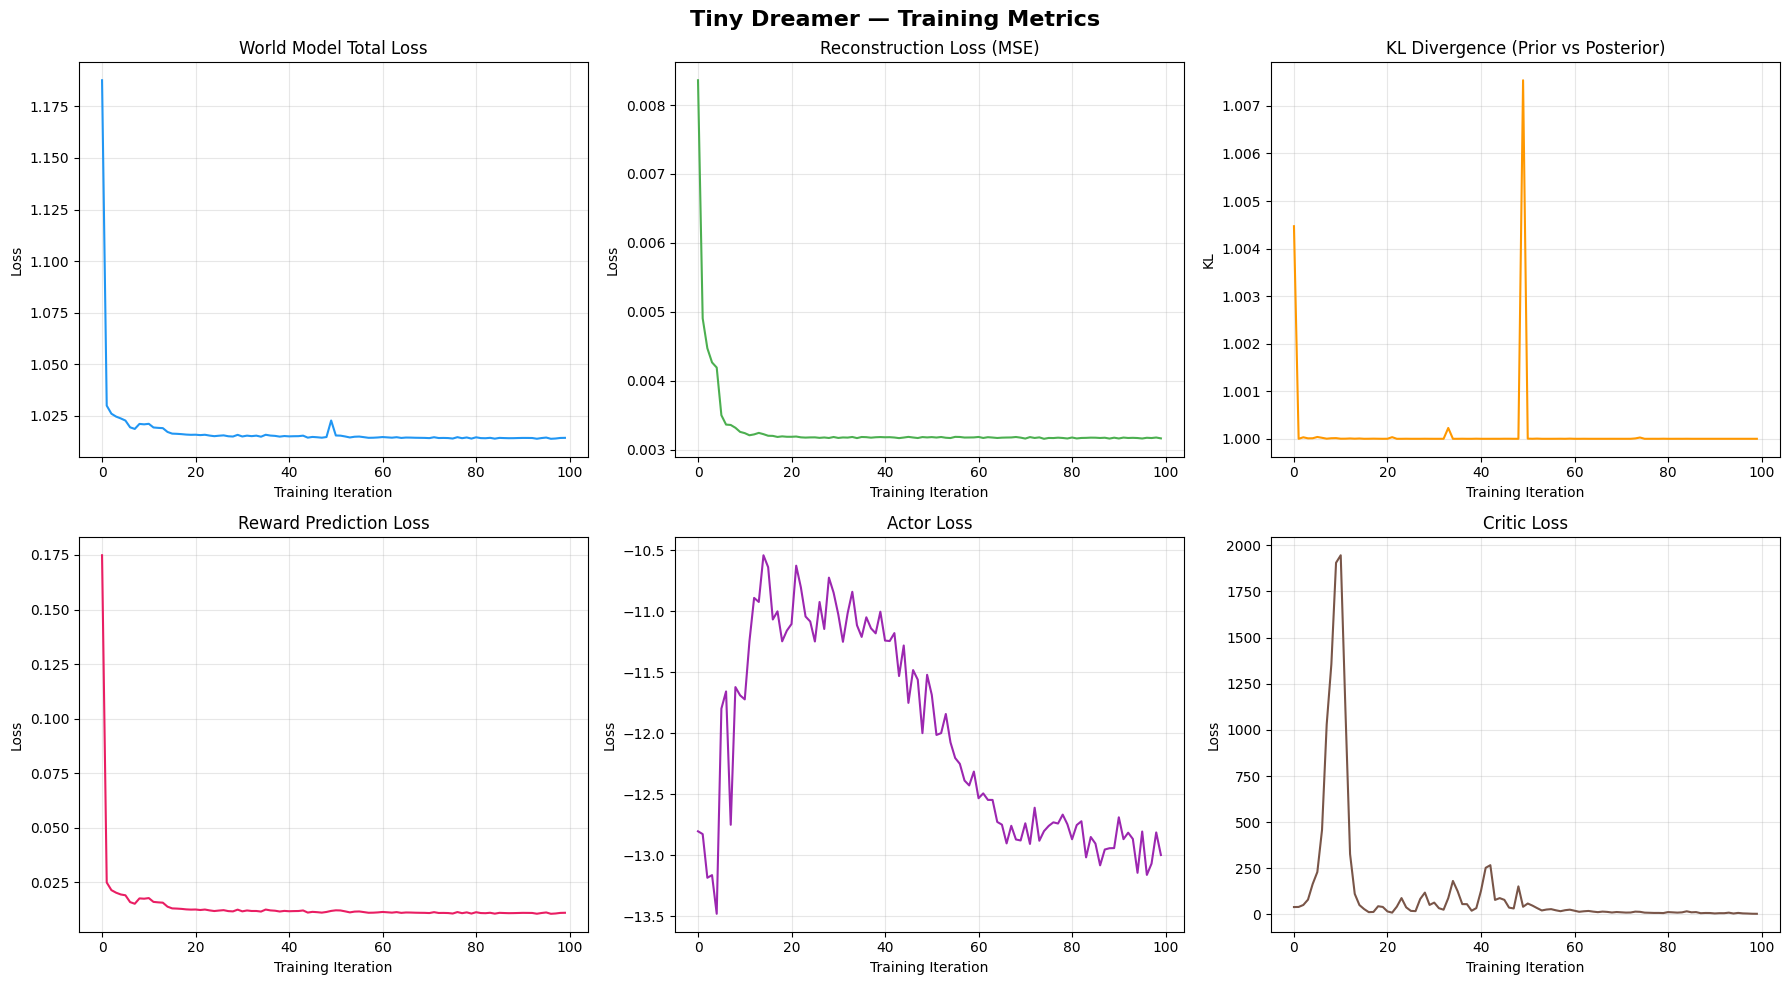

✅ Training curves saved.


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Tiny Dreamer — Training Metrics", fontsize=16, fontweight="bold")

metrics = dreamer.train_metrics

# World model total loss
axes[0, 0].plot(metrics["world_loss"], color="#2196F3", linewidth=1.5)
axes[0, 0].set_title("World Model Total Loss")
axes[0, 0].set_xlabel("Training Iteration")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(metrics["recon_loss"], color="#4CAF50", linewidth=1.5)
axes[0, 1].set_title("Reconstruction Loss (MSE)")
axes[0, 1].set_xlabel("Training Iteration")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].grid(True, alpha=0.3)

# KL divergence
axes[0, 2].plot(metrics["kl_loss"], color="#FF9800", linewidth=1.5)
axes[0, 2].set_title("KL Divergence (Prior vs Posterior)")
axes[0, 2].set_xlabel("Training Iteration")
axes[0, 2].set_ylabel("KL")
axes[0, 2].grid(True, alpha=0.3)

# Reward prediction loss
axes[1, 0].plot(metrics["reward_loss"], color="#E91E63", linewidth=1.5)
axes[1, 0].set_title("Reward Prediction Loss")
axes[1, 0].set_xlabel("Training Iteration")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].grid(True, alpha=0.3)

# Actor loss
axes[1, 1].plot(metrics["actor_loss"], color="#9C27B0", linewidth=1.5)
axes[1, 1].set_title("Actor Loss")
axes[1, 1].set_xlabel("Training Iteration")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].grid(True, alpha=0.3)

# Critic loss
axes[1, 2].plot(metrics["critic_loss"], color="#795548", linewidth=1.5)
axes[1, 2].set_title("Critic Loss")
axes[1, 2].set_xlabel("Training Iteration")
axes[1, 2].set_ylabel("Loss")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.VIDEO_DIR, "training_curves.png"), dpi=150)
plt.show()
print("✅ Training curves saved.")

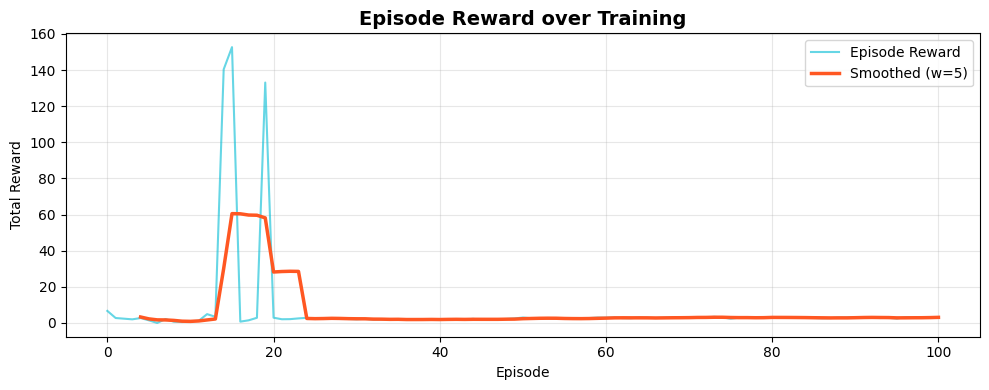

✅ Episode reward plot saved.


In [16]:
# Episode reward over training
if metrics["episode_reward"]:
    plt.figure(figsize=(10, 4))
    plt.plot(metrics["episode_reward"], color="#00BCD4", linewidth=1.5, alpha=0.6,
             label="Episode Reward")

    # Smoothed reward (moving average, window=5)
    if len(metrics["episode_reward"]) > 5:
        window = 5
        smoothed = np.convolve(metrics["episode_reward"],
                               np.ones(window) / window, mode="valid")
        plt.plot(range(window - 1, len(metrics["episode_reward"])),
                 smoothed, color="#FF5722", linewidth=2.5, label=f"Smoothed (w={window})")

    plt.title("Episode Reward over Training", fontsize=14, fontweight="bold")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.VIDEO_DIR, "episode_rewards.png"), dpi=150)
    plt.show()
    print("✅ Episode reward plot saved.")

---
## 11. Evaluation — n-step Prediction Quality

We quantitatively evaluate the world model by computing:

1. **Reconstruction MSE**: How well the decoder reconstructs ground-truth frames.
2. **Prediction MSE over K steps**: How prediction error grows as we imagine further ahead.
3. **Reward prediction accuracy**: Correlation between predicted and actual rewards.

In [17]:
def evaluate_world_model(dreamer: TinyDreamer, env: gym.Env,
                         num_episodes: int = 5, max_steps: int = 50):
    """Quantitatively evaluate the world model's prediction accuracy.

    For each episode:
        - Observe the first frame (encode + posterior).
        - Imagine forward K steps using the prior/actor.
        - Compare predicted frames and rewards to ground truth.

    Returns a dictionary of metrics for analysis.
    """
    import cv2

    dreamer.encoder.eval()
    dreamer.rssm.eval()
    dreamer.decoder.eval()
    dreamer.reward_model.eval()
    dreamer.actor.eval()

    step_mse = {}
    reward_pred_errors = []
    all_gt_rewards = []
    all_pred_rewards = []

    for ep in range(num_episodes):
        obs, _ = env.reset()
        frame = preprocess_frame(env.render(), dreamer.cfg)

        with torch.no_grad():
            frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
            embed = dreamer.encoder(frame_t)
            h, z = dreamer.rssm.initial_state(1)
            prev_action = torch.zeros(1, dreamer.cfg.ACTION_DIM, device=DEVICE)
            h, z, _, _, _, _ = dreamer.rssm.observe_step(h, z, prev_action, embed)

        for step in range(max_steps):
            with torch.no_grad():
                # Actor picks action
                action_t, _ = dreamer.actor(h, z)
                action = action_t.cpu().numpy().flatten()

                # Real environment step
                obs, gt_reward, terminated, truncated, _ = env.step(action)
                if terminated or truncated:
                    break
                gt_frame = preprocess_frame(env.render(), dreamer.cfg)

                # Imagine step in world model
                h, z = dreamer.rssm.imagine_step(h, z, action_t)
                pred_frame = dreamer.decoder(h, z)[0].cpu().numpy()  # (C, H, W)
                pred_reward = dreamer.reward_model(h, z).item()

            # Compute per-step MSE
            mse = np.mean((gt_frame - pred_frame) ** 2)
            if step not in step_mse:
                step_mse[step] = []
            step_mse[step].append(mse)

            all_gt_rewards.append(gt_reward)
            all_pred_rewards.append(pred_reward)
            reward_pred_errors.append(abs(gt_reward - pred_reward))

    # Aggregate step-wise MSE
    avg_step_mse = {s: np.mean(vals) for s, vals in step_mse.items()}

    return {
        "step_mse": avg_step_mse,
        "gt_rewards": all_gt_rewards,
        "pred_rewards": all_pred_rewards,
        "reward_mae": np.mean(reward_pred_errors),
    }


# Run evaluation
print("Evaluating world model prediction accuracy...")
eval_results = evaluate_world_model(dreamer, env, num_episodes=5, max_steps=40)
print(f"✅ Evaluation complete.")
print(f"   Reward prediction MAE: {eval_results['reward_mae']:.4f}")

Evaluating world model prediction accuracy...
✅ Evaluation complete.
   Reward prediction MAE: 0.0503


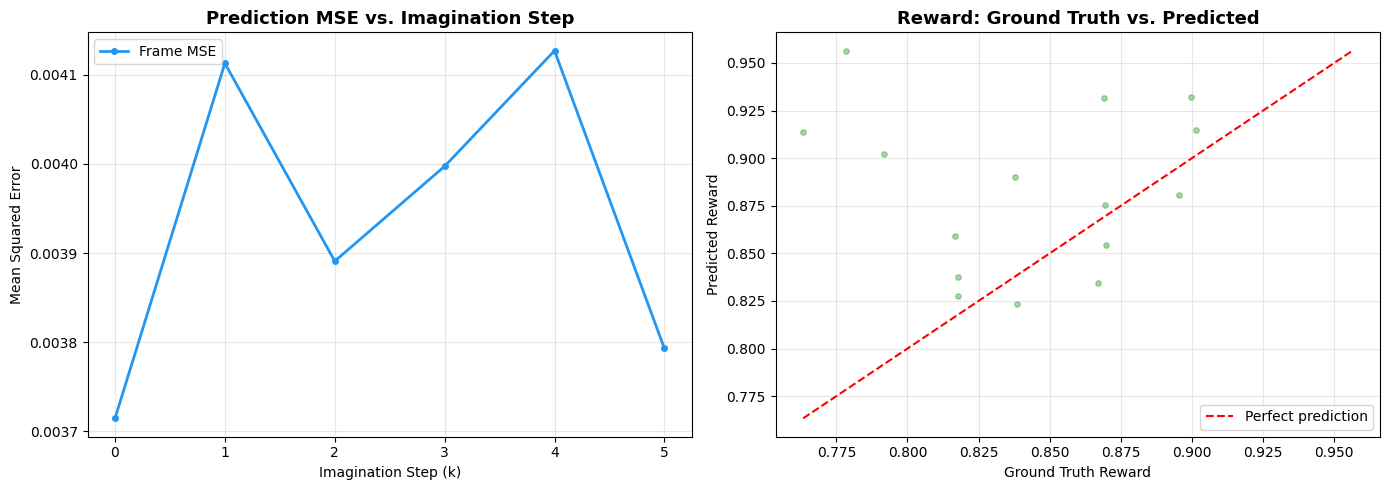

✅ Evaluation plots saved.


In [18]:
# Plot: Prediction MSE vs. Imagination Step
steps = sorted(eval_results["step_mse"].keys())
mses = [eval_results["step_mse"][s] for s in steps]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frame prediction MSE over steps
axes[0].plot(steps, mses, marker="o", color="#2196F3", linewidth=2,
             markersize=4, label="Frame MSE")
axes[0].set_title("Prediction MSE vs. Imagination Step", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Imagination Step (k)")
axes[0].set_ylabel("Mean Squared Error")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Reward: predicted vs actual
axes[1].scatter(eval_results["gt_rewards"], eval_results["pred_rewards"],
                alpha=0.5, s=15, color="#4CAF50")
r_min = min(min(eval_results["gt_rewards"]), min(eval_results["pred_rewards"]))
r_max = max(max(eval_results["gt_rewards"]), max(eval_results["pred_rewards"]))
axes[1].plot([r_min, r_max], [r_min, r_max], "--", color="red",
             linewidth=1.5, label="Perfect prediction")
axes[1].set_title("Reward: Ground Truth vs. Predicted", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Ground Truth Reward")
axes[1].set_ylabel("Predicted Reward")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(cfg.VIDEO_DIR, "evaluation_metrics.png"), dpi=150)
plt.show()
print("✅ Evaluation plots saved.")

---
## 12. n-step Prediction Visualization

The most important visualization: comparing what the world model **predicts** at each
time step versus what **actually happens** in the environment. This directly demonstrates
the effectiveness (or limitations) of the learned world model.

Generating n-step prediction visualization...


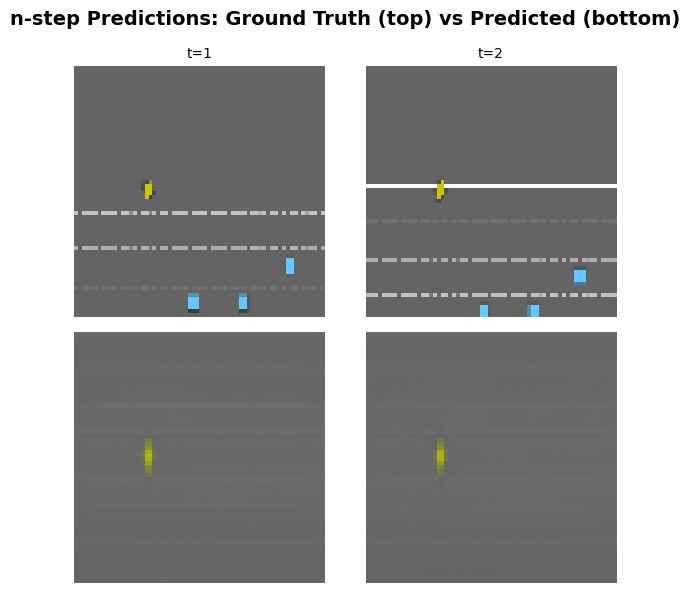

✅ Prediction grid saved to videos/prediction_grid.png
✅ Prediction video saved to videos/prediction_comparison_final.mp4


In [19]:
def visualize_predictions(dreamer: TinyDreamer, env: gym.Env,
                           n_steps: int = 20, save_dir: str = "videos"):
    """Create a comprehensive visualization of n-step predictions.

    Generates:
        1. A grid image showing ground truth vs predicted frames at selected steps.
        2. A side-by-side MP4 video.
    """
    import cv2

    dreamer.encoder.eval()
    dreamer.rssm.eval()
    dreamer.decoder.eval()
    dreamer.actor.eval()

    obs, _ = env.reset()
    frame = preprocess_frame(env.render(), dreamer.cfg)

    with torch.no_grad():
        frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
        embed = dreamer.encoder(frame_t)
        h, z = dreamer.rssm.initial_state(1)
        prev_action = torch.zeros(1, dreamer.cfg.ACTION_DIM, device=DEVICE)
        h, z, _, _, _, _ = dreamer.rssm.observe_step(h, z, prev_action, embed)

    gt_frames = []
    pred_frames = []
    actions_taken = []

    for step in range(n_steps):
        with torch.no_grad():
            action_t, _ = dreamer.actor(h, z)
            action = action_t.cpu().numpy().flatten()
            actions_taken.append(action.copy())

            # Ground truth
            obs, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                break
            gt_raw = env.render()
            gt_resized = cv2.resize(gt_raw, (dreamer.cfg.IMG_WIDTH, dreamer.cfg.IMG_HEIGHT))
            gt_frames.append(gt_resized)

            # Prediction
            h, z = dreamer.rssm.imagine_step(h, z, action_t)
            recon = dreamer.decoder(h, z)[0].cpu().numpy().transpose(1, 2, 0)
            pred_img = (np.clip(recon, 0, 1) * 255).astype(np.uint8)
            pred_frames.append(pred_img)

    # --- Grid visualization (selected timesteps) ---
    display_steps = list(range(0, len(pred_frames), max(1, len(pred_frames) // 8)))[:8]
    if display_steps:
        fig, axes = plt.subplots(2, len(display_steps), figsize=(3 * len(display_steps), 6))
        fig.suptitle("n-step Predictions: Ground Truth (top) vs Predicted (bottom)",
                     fontsize=14, fontweight="bold")

        for col, s in enumerate(display_steps):
            axes[0, col].imshow(gt_frames[s])
            axes[0, col].set_title(f"t={s+1}", fontsize=10)
            axes[0, col].axis("off")

            axes[1, col].imshow(pred_frames[s])
            axes[1, col].axis("off")

        axes[0, 0].set_ylabel("Ground Truth", fontsize=12)
        axes[1, 0].set_ylabel("Predicted", fontsize=12)
        plt.tight_layout()
        grid_path = os.path.join(save_dir, "prediction_grid.png")
        plt.savefig(grid_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✅ Prediction grid saved to {grid_path}")

    # --- Side-by-side video ---
    video_frames = []
    for i in range(len(pred_frames)):
        combined = np.concatenate([gt_frames[i], pred_frames[i]], axis=1)
        video_frames.append(combined)

    video_path = os.path.join(save_dir, "prediction_comparison_final.mp4")
    if video_frames:
        imageio.mimsave(video_path, video_frames, fps=10)
        print(f"✅ Prediction video saved to {video_path}")

    return gt_frames, pred_frames


# Generate final prediction visualization
print("Generating n-step prediction visualization...")
gt, pred = visualize_predictions(dreamer, env, n_steps=30, save_dir=cfg.VIDEO_DIR)

---
## 13. Final Evaluation: Full Episode Rollout

We run the fully trained agent for several complete episodes in the real environment
and record a video of its driving behavior.

In [20]:
def record_agent_episode(dreamer: TinyDreamer, env: gym.Env,
                          max_steps: int = 200, save_path: str = "videos/agent_driving.mp4"):
    """Record a full episode of the trained agent driving.

    Uses the encoder + RSSM (posterior with real observations) + actor
    to select actions in the real environment.

    Returns the total episode reward.
    """
    dreamer.encoder.eval()
    dreamer.rssm.eval()
    dreamer.actor.eval()

    obs, _ = env.reset()
    frame = preprocess_frame(env.render(), dreamer.cfg)
    h, z = dreamer.rssm.initial_state(1)
    # FIX: track the previous action so the RSSM receives the true action history
    # rather than always receiving a zero vector (which breaks the recurrent dynamics).
    prev_action_t = torch.zeros(1, dreamer.cfg.ACTION_DIM, device=DEVICE)

    frames = [env.render()]
    total_reward = 0.0
    step = 0

    while step < max_steps:
        with torch.no_grad():
            frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
            embed = dreamer.encoder(frame_t)
            # Pass the actual previous action, not zeros every step
            h, z, _, _, _, _ = dreamer.rssm.observe_step(h, z, prev_action_t, embed)
            action_t, _ = dreamer.actor(h, z)
            prev_action_t = action_t  # Update for the next step
            action = action_t.cpu().numpy().flatten()

        obs, reward, terminated, truncated, _ = env.step(action)
        frame = preprocess_frame(env.render(), dreamer.cfg)
        frames.append(env.render())
        total_reward += reward
        step += 1

        if terminated or truncated:
            break

    # Save video
    if frames:
        imageio.mimsave(save_path, frames, fps=15)

    return total_reward, step, frames


# Run evaluation episodes
print("Running evaluation episodes...")
eval_rewards = []
eval_steps = []

for ep in range(5):
    video_path = os.path.join(cfg.VIDEO_DIR, f"agent_episode_{ep + 1}.mp4")
    reward, steps, _ = record_agent_episode(dreamer, env, max_steps=200,
                                            save_path=video_path)
    eval_rewards.append(reward)
    eval_steps.append(steps)
    print(f"   Episode {ep + 1}: Reward = {reward:.2f}, Steps = {steps}")

print(f"\n✅ Evaluation Summary:")
print(f"   Mean Reward : {np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}")
print(f"   Mean Steps  : {np.mean(eval_steps):.1f}")
print(f"   Videos saved to {cfg.VIDEO_DIR}/")


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Running evaluation episodes...
   Episode 1: Reward = 2.40, Steps = 4


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


   Episode 2: Reward = 3.10, Steps = 5


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


   Episode 3: Reward = 4.07, Steps = 6


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 150) to (608, 160) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


   Episode 4: Reward = 4.23, Steps = 6
   Episode 5: Reward = 2.37, Steps = 4

✅ Evaluation Summary:
   Mean Reward : 3.23 ± 0.79
   Mean Steps  : 5.0
   Videos saved to videos/


---
## 14. Results Summary & Quantitative Metrics

This section compiles all key metrics into a summary table for the final report.

In [21]:
# Compile summary metrics
print("=" * 70)
print("  RESULTS SUMMARY")
print("=" * 70)

summary = {
    "Final World Model Loss": f"{metrics['world_loss'][-1]:.4f}",
    "Final Reconstruction Loss": f"{metrics['recon_loss'][-1]:.4f}",
    "Final KL Divergence": f"{metrics['kl_loss'][-1]:.4f}",
    "Final Reward Pred. Loss": f"{metrics['reward_loss'][-1]:.4f}",
    "Final Actor Loss": f"{metrics['actor_loss'][-1]:.4f}",
    "Final Critic Loss": f"{metrics['critic_loss'][-1]:.4f}",
    "Reward Prediction MAE": f"{eval_results['reward_mae']:.4f}",
    "Eval Mean Reward": f"{np.mean(eval_rewards):.2f} ± {np.std(eval_rewards):.2f}",
    "Eval Mean Steps": f"{np.mean(eval_steps):.1f}",
    "Total Training Iterations": cfg.TOTAL_TRAIN_ITERS,
    "Replay Buffer Size": len(replay_buffer),
}

for key, val in summary.items():
    print(f"  {key:30s} : {val}")

print("=" * 70)

  RESULTS SUMMARY
  Final World Model Loss         : 1.0143
  Final Reconstruction Loss      : 0.0032
  Final KL Divergence            : 1.0000
  Final Reward Pred. Loss        : 0.0111
  Final Actor Loss               : -12.9982
  Final Critic Loss              : 3.4979
  Reward Prediction MAE          : 0.0503
  Eval Mean Reward               : 3.23 ± 0.79
  Eval Mean Steps                : 5.0
  Total Training Iterations      : 100
  Replay Buffer Size             : 22000


In [22]:
# Summary table as a DataFrame for the report
import pandas as pd

summary_df = pd.DataFrame(
    list(summary.items()), columns=["Metric", "Value"]
)
summary_df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "left")]}]
)

,Metric,Value
0,Final World Model Loss,1.0143
1,Final Reconstruction Loss,0.0032
2,Final KL Divergence,1.0000
3,Final Reward Pred. Loss,0.0111
4,Final Actor Loss,-12.9982
5,Final Critic Loss,3.4979
6,Reward Prediction MAE,0.0503
7,Eval Mean Reward,3.23 ± 0.79
8,Eval Mean Steps,5.0
9,Total Training Iterations,100


---
## 15. Dream Sequence — Imagined Rollout Video

This final visualization generates a **pure imagination** video: the world model
rolls out a trajectory entirely in latent space (no real environment interaction),
and the decoder reconstructs what the agent "dreams" will happen.

In [23]:
def generate_dream_video(dreamer: TinyDreamer, env: gym.Env,
                          dream_steps: int = 50, save_path: str = "videos/dream.mp4"):
    """Generate a video of the agent's imagination — no real env steps.

    Starting from a single real observation, the world model imagines
    forward for `dream_steps` steps using only the learned dynamics
    and actor. The decoder reconstructs each imagined frame.
    """
    dreamer.encoder.eval()
    dreamer.rssm.eval()
    dreamer.decoder.eval()
    dreamer.actor.eval()

    # Get initial state from one real observation
    obs, _ = env.reset()
    frame = preprocess_frame(env.render(), dreamer.cfg)

    with torch.no_grad():
        frame_t = torch.tensor(frame, device=DEVICE).unsqueeze(0)
        embed = dreamer.encoder(frame_t)
        h, z = dreamer.rssm.initial_state(1)
        prev_action = torch.zeros(1, dreamer.cfg.ACTION_DIM, device=DEVICE)
        h, z, _, _, _, _ = dreamer.rssm.observe_step(h, z, prev_action, embed)

    dream_frames = []
    dream_rewards = []

    # Imagine forward step by step
    for step in range(dream_steps):
        with torch.no_grad():
            # Actor selects action in imagination
            action_t, _ = dreamer.actor(h, z)

            # RSSM imagines the next state
            h, z = dreamer.rssm.imagine_step(h, z, action_t)

            # Decode the imagined state to an image
            recon = dreamer.decoder(h, z)[0].cpu().numpy().transpose(1, 2, 0)
            img = (np.clip(recon, 0, 1) * 255).astype(np.uint8)
            dream_frames.append(img)

            # Predict reward in the dream
            reward = dreamer.reward_model(h, z).item()
            dream_rewards.append(reward)

    # Save dream video
    if dream_frames:
        imageio.mimsave(save_path, dream_frames, fps=10)
        print(f"✅ Dream video saved: {save_path}")
        print(f"   Dream total reward: {sum(dream_rewards):.2f}")
        print(f"   Dream mean reward per step: {np.mean(dream_rewards):.4f}")

    return dream_frames, dream_rewards


# Generate dream video
dream_frames, dream_rewards = generate_dream_video(
    dreamer, env, dream_steps=50,
    save_path=os.path.join(cfg.VIDEO_DIR, "dream_sequence.mp4")
)

✅ Dream video saved: videos/dream_sequence.mp4
   Dream total reward: 47.40
   Dream mean reward per step: 0.9481


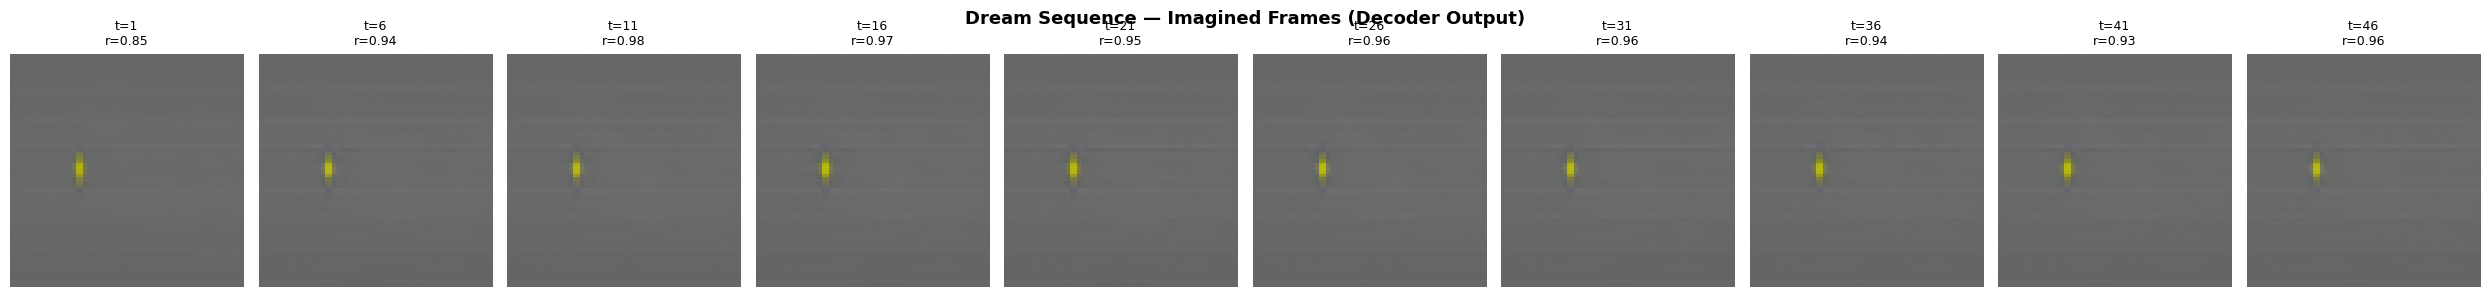

✅ Dream frames visualization saved.


In [24]:
# Visualize a few dream frames
if dream_frames:
    display_indices = list(range(0, len(dream_frames), max(1, len(dream_frames) // 10)))[:10]
    fig, axes = plt.subplots(1, len(display_indices), figsize=(2.5 * len(display_indices), 3))
    fig.suptitle("Dream Sequence — Imagined Frames (Decoder Output)",
                 fontsize=13, fontweight="bold")

    for i, idx in enumerate(display_indices):
        axes[i].imshow(dream_frames[idx])
        axes[i].set_title(f"t={idx+1}\nr={dream_rewards[idx]:.2f}", fontsize=9)
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.VIDEO_DIR, "dream_frames.png"), dpi=150)
    plt.show()
    print("✅ Dream frames visualization saved.")

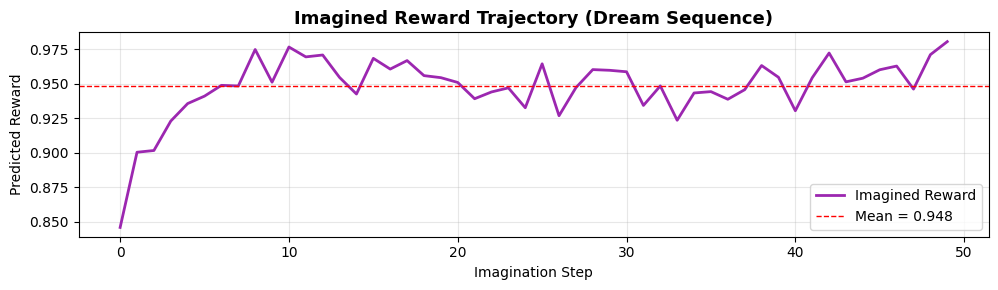

✅ Dream reward trajectory saved.


In [25]:
# Plot dream reward trajectory
plt.figure(figsize=(10, 3))
plt.plot(dream_rewards, color="#9C27B0", linewidth=2, label="Imagined Reward")
plt.axhline(y=np.mean(dream_rewards), color="red", linestyle="--",
            linewidth=1, label=f"Mean = {np.mean(dream_rewards):.3f}")
plt.title("Imagined Reward Trajectory (Dream Sequence)", fontsize=13, fontweight="bold")
plt.xlabel("Imagination Step")
plt.ylabel("Predicted Reward")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.VIDEO_DIR, "dream_reward_trajectory.png"), dpi=150)
plt.show()
print("✅ Dream reward trajectory saved.")

---
## 16. Save Model Checkpoints

In [26]:
# Save all model weights for reproducibility
checkpoint = {
    "encoder": dreamer.encoder.state_dict(),
    "rssm": dreamer.rssm.state_dict(),
    "decoder": dreamer.decoder.state_dict(),
    "reward_model": dreamer.reward_model.state_dict(),
    "actor": dreamer.actor.state_dict(),
    "critic": dreamer.critic.state_dict(),
    "config": cfg.__dict__,
    "train_metrics": dreamer.train_metrics,
}
checkpoint_path = "tiny_dreamer_checkpoint.pt"
torch.save(checkpoint, checkpoint_path)
print(f"✅ Model checkpoint saved to {checkpoint_path}")

# Clean up
env.close()
print("✅ Environment closed.")

✅ Model checkpoint saved to tiny_dreamer_checkpoint.pt
✅ Environment closed.


---
## 17. Files Generated

| File | Description |
|---|---|
| `videos/prediction_iter_*.mp4` | Side-by-side prediction vs ground truth at training checkpoints |
| `videos/prediction_comparison_final.mp4` | Final n-step prediction comparison video |
| `videos/prediction_grid.png` | Grid of ground truth vs predicted frames |
| `videos/agent_episode_*.mp4` | Full driving episodes with the trained agent |
| `videos/dream_sequence.mp4` | Pure imagination rollout (no real env) |
| `videos/dream_frames.png` | Visualization of selected dream frames |
| `videos/dream_reward_trajectory.png` | Imagined reward over dream steps |
| `videos/training_curves.png` | Loss curves for all model components |
| `videos/episode_rewards.png` | Episode reward progression |
| `videos/evaluation_metrics.png` | Prediction MSE and reward accuracy plots |
| `tiny_dreamer_checkpoint.pt` | Saved model weights and training metrics |